# III. Modélisation Avancée et Arbitrage Financier (XGBoost vs Baseline)

Ce notebook présente l'entraînement de notre modèle cible XGBoost, l'analyse de son explicabilité, puis sa comparaison avec la Baseline. Nous analyserons la calibration des probabilités et le profit économique réel pour valider le modèle final.

## Import des librairies & fonctions

In [16]:
# Commandes rechargement automatique
%load_ext autoreload
%autoreload 2

# Configuration de la racine du projet pour éviter le ModuleNotFoundError
import sys
from pathlib import Path

racine_projet = Path.cwd().parent
if str(racine_projet) not in sys.path:
    sys.path.append(str(racine_projet))

# Packages de manipulation des tableaux et DataFrames
import pandas as pd

# Packages pour représentation graphique
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

#package sklearn
from sklearn.inspection import permutation_importance
from sklearn.metrics import brier_score_loss

#package pour sauvegarder le modèle
import joblib

#import des fonctions de src.data_prep
from src.data_prep import (
    load_data,
    Feature_engineering,
    data_preprocessing
)
#import des fonctions de src.train
from src.train import (
    separation_data_train_test,
    extraire_variables_selectionnees,
    afficher_auc_par_nombre_variables_rfecv,
    assemblage_pipeline_global,
    optimisation_hyperparam_XGB_RSCV
)
#import des fonction de src.metrics
from src.metrics import (
    calcul_AUC,
    simuler_profits_top_k,
    model_evaluation,
    tracer_courbe_calibartion,
    portrait_robot_clients_churn,
    generate_rapport_final,
    tracer_courbes_roc,
    tracer_matrices_confusion, 
    tracer_courbes_profit_top_k,  
    calculer_seuil, 
    tracer_courbes_profit_seuils,
    tracer_courbe_lift
)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Import et vérification des données

In [17]:
#Import du fichier de données
df= load_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("\nDimensions des données :")
print(f"  - Variables explicatives  : {df.shape[0]} lignes, {df.shape[1]} colonnes")



Nom du fichier : 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

Dimensions des données :
  - Variables explicatives  : 7043 lignes, 21 colonnes


## 2. Feature engineering et preprocessing

De nouvelles variables ont été ajoutées pour améliorer les performances de l'algorithme XGBoost (XGB).

- **`tenure_tranches`**: variable découpant la tenure (ancienneté) en tranches par année (6 catégories) :  
$ \text{tenure\_0\_1yr}$: ancienneté inférieure ou égale à un an (nouveaux clients)  
$ \text{tenure\_1\_2yr}$: ancienneté entre 1 à 2 ans  
$ \text{tenure\_2\_3yr}$: ancienneté entre 2 à 3 ans  
$ \text{tenure\_3\_4yr}$: ancienneté entre 3 à 4 ans  
$ \text{tenure\_4\_5yr}$: ancienneté entre 4 à 5 ans  
$ \text{tenure\_5\_6yr}$: ancienneté entre 5 à 6 ans  

- **`charge_par_mois_tenure`** : calcul des frais par mois d'ancienneté ce qui représente les dépenses réelles du client par mois. <br>  
$ \text{charge\_par\_mois\_tenure} = \frac{\text{TotalCharges}}{\text{tenure}} $  


- **`ratio_evolution_facture`**: ratio d'évolution de la facture. Un ratio proche de 1 montre une stabilité
contrairement à ratio supérieur à 1 qui marque une augmentation. <br><br> 
$ \text{ratio\_evolution\_facture} = \frac{\text{MonthlyCharges}}{\text{charge\_par\_mois\_tenure}} $  

- **`a_totalcharges_is_missing`**: variable binaire indiquant si TotalCharges est manquant ou non (1 si manquant, 0 sinon)


In [18]:
#Feature engineering et séparation des variables explicatives et de la variable cible
X, y = Feature_engineering(df)
print("\nDimensions des données après Feature Engineering :")
print(f"X: {X.shape}, y: {y.shape}")


Dimensions du DataFrame après Feature Engineering :
Nombre de lignes: 7043, Nombre de colonnes: 25

Dimensions des données après Feature Engineering :
X: (7043, 24), y: (7043,)


### 2.1 Séparation des données de training et de test
la variable "customerID" a até sauvegardée dans le Series "id_test" avant dêtre supprimée vu qu'elle n'a pas d'impact sur les prédictions et ne sera pas utilisée dans les calculs.  
La variable "id_test" sera récupéree dans le fichier de scoring.

In [19]:
X_train, X_test, y_train, y_test, id_test = separation_data_train_test(X, y)

print("\nDimensions des données après séparation train/test :")
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")


Dimensions des données après séparation train/test :
X_train : (5634, 23)
X_test : (1409, 23)
y_train : (5634,)
y_test : (1409,)


### 2.2 Prétraitement

#### Étape : préparation des variables numériques (Pipeline)

Pour traiter les variables numériques, nous mettons en place un sous-pipeline séquentiel composé de deux transformations :

1. **`SimpleImputer(strategy="median")` (imputation des valeurs manquantes)**  
    Cette étape remplace chaque valeur manquante par la **médiane** de la colonne calculée sur le jeu d'entraînement. Dans notre jeux de données, il n'y a que la variable "TotalCharges" qui contient des variables manquantes ('NaN').  
   Bien qu'il n'y ait pas de valeurs aberrantes (*outliers*), imputer par la médiane reste un bon choix si on change de données.  

2. **`StandardScaler()` (normalisation / mise à l'échelle)**  
   Les variables numériques ont des ordres de grandeur différents (ex: SeniorCitizen entre 0 et 1, et le TotalCharges entre 18.8 et 8684.8).  
   Bien que les modèles basés sur des arbres (ici XGBoost) soient insensibles aux différences d'échelle, cette étape reste une excellente pratique pour rendre les coefficients directement comparables entre eux pour évaluer l'importance des variables.

#### Étape : préparation des variables catégorielles (Pipeline)

Pour traiter les variables catégorielles, nous mettons en place un sous-pipeline séquentiel composé de deux étapes de transformation essentielles :

1. **`SimpleImputer(strategy="constant", fill_value="missing")` (gestion des valeurs manquantes)**  
   À l'instar des variables numériques, cette étape remplace chaque cellule vide (`NaN`) par une nouvelle catégorie textuelle explicite nommée `"missing"` bien que les variables catégorielles de notre jeu de données ne comporte pas de 'NaN'.

2. **`OneHotEncoder(handle_unknown="ignore", sparse_output=False)` (encodage binaire)**  
   Nous avons choisi le 'OneHotEncoder' pour encoder les variables catégorielles. Les paramères suivants sont utilisés :  
     * **handle_unknown="ignore"** : ce paramètre est indispensable pour la robustesse si on utilise d'autres jeux de données qui contiennent une nouvelle catégorie inconnue. L'encodeur attribuera la valeur `0` à toutes les colonnes générées pour cette ligne.  
     * **sparse_output=False** : pour forcer l'encodeur à retourner une matrice standard (un tableau NumPy dense) plutôt qu'une matrice creuse (sparse matrix). 



In [22]:
preprocesseur = data_preprocessing(X_train)

Colonnes numériques : Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'charge_par_mois_tenure', 'ratio_evolution_facture',
       'a_totalcharges_is_missing'],
      dtype='str')
Colonnes catégorielles : Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'tenure_tranches'],
      dtype='str')


In [23]:
#Affichage pipeline
from sklearn import set_config
set_config(display='diagram')

# Affichage du preprocesseur
preprocesseur



,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('var_num', ...), ('var_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## 3. Pipeline global et entrainement du modèle

### 3.1 Assemblage du Pipeline global (modélisation et sélection de variables)

Pour finaliser notre architecture de Machine Learning, nous regroupons la préparation des données, la sélection de variables et l'algorithme prédictif au sein du **Pipeline global**. Nous allons appliquer un algorithme d'élimination récursive des variables par validation croisée (RFECV). Le but étant d'éliminer les variables les moins pertinentes avant l'évaluation final de notre modèle.

Voici le détail des trois composants de notre pipeline :

1. **`preprocessing` (`ColumnTransformer`)**
   Il s'agit du bloc d'assemblage configuré précédemment (imputation des valeurs manquantes, encodage, ...)

2. **`selection` (`RFECV` - Recursive Feature Elimination with Cross-Validation)**  
  L'algorithme est utilsé avec les paramètres:
   * Validation Croisée (`cv=5`) : pour éviter le sur-apprentissage, le score de chaque sous-ensemble de variables est évalué à l'aide d'une validation croisée en 5 blocs.
   * Métrique de performance (`scoring='roc_auc'`) : l'**AUC-ROC** est la métrique parfaitement adaptée à notre jeu de données moyennement déséquilibré.

3. **`classification` (`XGBClassifier`)**  
   **Modèle final :** une fois le sous-ensemble de variables optimal identifié par la `RFECV`, les données filtrées sont transmises à notre classificateur final XGBoost qui sera utilisé avec les l'yperparamètres clés suivants:
     * n_estimators=80 : limite la construction du modèle à 80 arbres de décision séquentiels.
     * eval_metric='logloss : spécifie explicitement la fonction de perte (perte logarithmique).
     * random_state=set_seed` : fixe la graine afin de garantir la reproductibilité  exacte des résultats.

In [24]:
# Assemblage du Pipeline global
# Le pipeline applique les transformations, filtre via RFECV, puis entraîne le modèle
set_seed = 42  # Définir une graine pour la reproductibilité

xgbc_pipeline=assemblage_pipeline_global(preprocesseur, set_seed)




### 3.2 Entrainement du modèle

In [25]:
#entrainement du modele avec le pipeline complet
xgbc_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['gender','SeniorCitizen','Partner',...,'charge_par_mois_tenure', 'ratio_evolution_facture','a_totalcharges_is_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('var_num', ...), ('var_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [26]:
#Récupération des variables conservées par l'algorithme RFECV 
features_gardees, rfecv_step = extraire_variables_selectionnees(xgbc_pipeline)
print(features_gardees)
print(type(rfecv_step))

RFECV : 38 variables conservées sur 54 initiales.

['var_num__SeniorCitizen', 'var_num__tenure', 'var_num__MonthlyCharges', 'var_num__TotalCharges', 'var_num__charge_par_mois_tenure', 'var_num__ratio_evolution_facture', 'var_cat__gender_Female', 'var_cat__Partner_No', 'var_cat__Dependents_No', 'var_cat__PhoneService_No', 'var_cat__MultipleLines_No', 'var_cat__MultipleLines_Yes', 'var_cat__InternetService_DSL', 'var_cat__InternetService_Fiber optic', 'var_cat__OnlineSecurity_No', 'var_cat__OnlineSecurity_Yes', 'var_cat__OnlineBackup_No', 'var_cat__OnlineBackup_Yes', 'var_cat__DeviceProtection_No', 'var_cat__DeviceProtection_Yes', 'var_cat__TechSupport_No', 'var_cat__TechSupport_Yes', 'var_cat__StreamingTV_No', 'var_cat__StreamingTV_Yes', 'var_cat__StreamingMovies_No', 'var_cat__StreamingMovies_Yes', 'var_cat__Contract_Month-to-month', 'var_cat__Contract_One year', 'var_cat__Contract_Two year', 'var_cat__PaperlessBilling_No', 'var_cat__PaymentMethod_Bank transfer (automatic)', 'var_cat__

* Le modèle initial comportait 54 variables après l'encodage.
* L'algorithme **`RFECV`** a éliminé 16 variables correspondant à certaines catégories par exemple :
La variable "gendre" a deux catégories "Male" et "Female".
la catégorie `var_cat_gender_Male` a été supprimée 
* Toutes les variables initiales du modèle ont été conservées et compris les variables ajoutées lors du feature-engineering à l'exception de la variable `a_totalcharges_is_missing` qui a été supprimée. Le fait de décomposer la variable "tenure" en tranches annuelles a peut être été suffisant pour détecter les lignes avec des valeurs initialement manquantes de "Totalcharges" qui correspondent aux nouveaux clients.


In [27]:
# Récupérer les scores moyens d'AUC calculée par validation croisée 
# pour chaque nombre de variables testé
afficher_auc_par_nombre_variables_rfecv(rfecv_step)


Évolution du score AUC selon le nombre de variables restantes :
Top 1 variables -> AUC moyen: 0.7289
Top 2 variables -> AUC moyen: 0.7925
Top 3 variables -> AUC moyen: 0.7974
Top 4 variables -> AUC moyen: 0.8089
Top 5 variables -> AUC moyen: 0.8147
Top 6 variables -> AUC moyen: 0.8162
Top 7 variables -> AUC moyen: 0.8137
Top 8 variables -> AUC moyen: 0.8118
Top 9 variables -> AUC moyen: 0.8158
Top 10 variables -> AUC moyen: 0.8145
Top 11 variables -> AUC moyen: 0.8123
Top 12 variables -> AUC moyen: 0.8171
Top 13 variables -> AUC moyen: 0.8176
Top 14 variables -> AUC moyen: 0.8188
Top 15 variables -> AUC moyen: 0.8163
Top 16 variables -> AUC moyen: 0.8170
Top 17 variables -> AUC moyen: 0.8169
Top 18 variables -> AUC moyen: 0.8160
Top 19 variables -> AUC moyen: 0.8151
Top 20 variables -> AUC moyen: 0.8176
Top 21 variables -> AUC moyen: 0.8200
Top 22 variables -> AUC moyen: 0.8203
Top 23 variables -> AUC moyen: 0.8207
Top 24 variables -> AUC moyen: 0.8191
Top 25 variables -> AUC moyen: 0

**L'AUC** moyen maximum **`(0.8236)`** est atteint avec **`38 variables`**.

In [28]:
 # Prédiction des probabilités
auc_train,auc_test= calcul_AUC(xgbc_pipeline, X_train, y_train, X_test, y_test)
print(f"\nAUC sur l'ensemble d'entraînement : {auc_train:.4f}")
print(f"AUC sur l'ensemble de test : {auc_test:.4f}")



AUC sur l'ensemble d'entraînement : 0.9868
AUC sur l'ensemble de test : 0.8184


Dans ce pipeline initial, l'algorithme XGBoost a été utilisé avec ses hyperparamètres par défaut (à l'excéption du paramètre $\text{n\_estimators}$ fixé à 80).  
L'algoithme  XGBoost a donc exploré des arbres profonds ($\text{max\_depth=6}$ par défaut soit $2^6$=64 feuilles).  
* `Sur le Train (AUC=0,9868)` : l'algorithme a appris les données d'entraînement quasiment par cœur, créant des règles ultra-spécifiques pour chaque client.  
* `Sur le Test (AUC=0,8184)` : face à des données inconnues par l'algorithme, les règles apprises n'ont pas fonctionnées. Le score a chuté lourdement à 0,8184.    

Nous allons appliquer un algorithme "RandomizedSearchCV" pour optimiser les hyperparamètres du XGBoost et aboutir à de meilleurs résultats.

### 3.3 Optimisation des Hyperparamètres (RandomizedSearchCV)

Après avoir nettoyé les données et sélectionné le sous-ensemble de variables le plus performant via la `RFECV`, nous procédons au réglage fin (*hyperparameter tuning*) de notre modèle **XGBoost** pour régler le problème de surrapprentissage rencontré en appliquant les paramètres par défaut.

Pour limiter le temps de calcul, le choix s'est porté sur le `RandomizedSearchCV` qui choisit de façon aléatoire un nombre fixe (`n_iter`=10) de combinaisons à tester et évaluer par validation croisée pour garantir la robustesse et éviter le surapprentissage.

#### 3.3.1 Grille d'exploration des Hyperparamètres
Pour optimiser notre modèle, nous ajustons simultanément quatre hyperparamètres clés de l'algorithme XGBoost :

| Nom du Paramètre | Rôle technique |
| :--- | :--- |
| **`n_estimators`**<br>`[100, 200, 300]` | nombre d'arbres construits en série. |
| **`max_depth`**<br>`[3, 5, 7]` | profondeur maximale de chaque arbre. | 
| **`learning_rate`**<br>`[0.01, 0.05, 0.1]` | vitesse d'apprentissage. |
| **`subsample`**<br>`[0.8, 1.0]` | fraction des lignes échantillonnées par arbre. |

In [29]:
#optimisation

searchCV_xgb = optimisation_hyperparam_XGB_RSCV(xgbc_pipeline, X_train, y_train)
print("Meilleur score AUC après tuning :", searchCV_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Meilleur score AUC après tuning : 0.8480066204672646


Nous constatons une amélioration de la métrique **`AUC-ROC (0.8480)`**.
L'optimisation des hyperparamètres a permis d'améliorer l'AUC moyen maximum **`(0.8236)`** calculé par la validation croisée.

#### 3.3.2 Afficher les meilleurs hyperparamètres trouvés

In [15]:
print("Meilleurs paramètres trouvés :")
print(searchCV_xgb.best_params_)

Meilleurs paramètres trouvés :
{'classification__subsample': 1.0, 'classification__n_estimators': 100, 'classification__max_depth': 3, 'classification__learning_rate': 0.05}


L'algorithme XGBoost atteint ses meilleurs performances avec des arbres de profondeur 3 (8 feuilles) et un pas d'apprentissage fixé à 0.05.

## 4. Métriques mathématiques (performance globale)

In [30]:
model_evaluation(searchCV_xgb, X_train, y_train, X_test, y_test)

AUC : 0.8674 (train) 0.8463 (test)
L'accuracy : 81.6116 % (train)
L'accuracy : 80.4826 % (test)

Rapport de classification (test) :

              precision    recall  f1-score   support

   Churn (0)       0.84      0.91      0.87      1035
   Churn (1)       0.68      0.50      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



* le modèle XGBoost optimisé affiche d'excellentes performances de classification. La proximité des scores entre le jeu d'entraînement et le jeu de test `(AUC : 0,8674 vs 0,8463 et Accuracy : 81,61 % vs 80,48 %)` démontre la très grande stabilité du modèle et l'absence de surapprentissage (overfitting).  

* En analysant le rapport de classification sur le jeu de test, on remarque que notre objectif de gagner en précision est atteint : le modèle privilégie `la précision sur la classe Churn (0,68) contre (0,50) du modèle baseline`. En contrepartie, le rappel se situe à 0,50, ce qui signifie qu'au seuil par défaut de 0,50, le modèle ne détecte qu'un client sur deux en situation de rupture (churn).

* L'optimisation via le modèle XGBoost permet d'augmenter l'AUC de test (**0,8463** contre **0,8413** pour la Baseline) et de faire bondir l'Accuracy globale de près de 7 points (**80,48 %** contre **73,81 %**).



## 5. Permutation Importance

Afin d'interpréter les décisions du modèle XGBoost et de comprendre les facteurs clés du churn, nous utilisons la méthode de la Permutation Importance évaluée directement sur le jeu de test. Le graphique qui suit présente le top 15 des variables ordonnées par leur pouvoir explicatif.

In [32]:
# Calcul de la permutation importance sur le jeu de test
resultat_permutation = permutation_importance(
    searchCV_xgb, X_test, y_test, 
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Création du DataFrame pour classer les variables
df_importance = pd.DataFrame({
    'Variable': X_test.columns,
    'Importance_Moyenne': resultat_permutation.importances_mean
}).sort_values(by='Importance_Moyenne', ascending=False)

# Top 15 pour le graphique
top_15_importance = df_importance.head(15)

print("--- Les 5 variables les plus importantes pour XGBoost ---")
print(top_15_importance.head(5))

# Representation graphique du top 15 des variables
fig = px.bar(
    top_15_importance, 
    x='Importance_Moyenne', 
    y='Variable',
    orientation='h',
    title="<b>Top 15 des variables clés du churn (Permutation Importance)",
    labels={'Importance_Moyenne': "Chute moyenne de l'AUC si la variable est supprimée"},
    color='Importance_Moyenne',
    color_continuous_scale='Oranges'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'}, width=800, height=600, title_x=0.5)
fig.write_image("../reports/figures/permutation_importance.png", scale=3)
fig.show()


--- Les 5 variables les plus importantes pour XGBoost ---
                   Variable  Importance_Moyenne
14                 Contract            0.087196
4                    tenure            0.030239
21  ratio_evolution_facture            0.014801
7           InternetService            0.009030
8            OnlineSecurity            0.005988


La variable **`Contract`** est à la tête du classement avec un score de **0.08**, cela signifie que si l'on détruit l'information de cette variable, l'AUC du modèle chute de 0,08 (passe de 0,8463 à 0,7663). C'est la preuve que cette variable est indispensable.  
Les variables peuvent être classées en trois catégories :
- **Finance/contrat (engagement):** cette catégorie contient les élements les plus influents tels que le type de contrat (mensuel, annuel, etc), ancienneté du client (tenure), évolution de la facture (ration_evolution_facture).  
On constate que les clients récents ou sans engagement de durée représentent de plus grands risques de churn.  
- **Satifaction/relationnel:** type de service et sécurité (InternetService, techSupport, OnlineSecurity), méthodes de paiement (Paymentmethod).
- **Démograhie :** l'âge (seniorCitizen) du client à aussi son influence.

## 6. Métriques Métier et Fiabilité

### 6.1 Courbe de profit cumulé (Top K%)

Les métriques de classification standards (l'AUC et l'Accuracy) évaluées précédemment au seuil par défaut de 0,50 ne permettent pas d'intégrer la réalité économique de l'entreprise.

Dans notre cas d'usage, un arbitrage financier doit être opéré :  
- coût offre = **15€**
- valeur sauvée = **120€**

Pour identifier la stratégie de ciblage la plus rentable, nous mettons en place une approche par **Top K%**. Cette simulation consiste à trier l'ensemble de nos clients du plus risqué au moins risqué selon les prédictions du modèle, puis à évaluer le bénéfice net généré pour chaque volume de campagne possible (en ciblant de 1 % à 100 % de la base de test).  

Le graphique interactif ci-dessous retrace l'évolution de ce profit cumulé et met en évidence la taille de campagne optimale pour maximiser les gains de l'entreprise.

In [35]:
cout_offre=15
valeur_sauvee=120

#probabiliés
y_pred_proba_XGB = searchCV_xgb.predict_proba(X_test)[:, 1]

seuil_optimal_XGB, profit_max_XGB, profits_XGB = simuler_profits_top_k(y_test, y_pred_proba_XGB, cout_offre, valeur_sauvee)

print(f"Modèle XGBoost - Budget Optimal : Il faut cibler le Top {seuil_optimal_XGB}% des clients les plus à risque.")
print(f"Profit maximum pour cette stratégie : {profit_max_XGB:,.2f} €")

tracer_courbes_profit_top_k(profits_XGB, "XGB", seuil_optimal_XGB)

Modèle XGBoost - Budget Optimal : Il faut cibler le Top 60% des clients les plus à risque.
Profit maximum pour cette stratégie : 29,565.00 €


**`Résultat :`** Le profit net maximal de **`29 565 €`** est atteint en ciblant exactement le **`top 60 %`** des clients les plus à risque.  
**`Interprétation :`** Le graphique ci-dessus offre un outil de pilotage budgétaire direct pour la direction marketing. Il prouve qu'au-delà de 60 % de clients contactés, la campagne devient contre-productive : le coût des offres envoyées à des clients fidèles (les faux positifs à 15 €) dépasse le gain des clients ciblés. C'est le point d'équilibre parfait du modèle.


### 6.2 Courbe de profit en fonction du seuil

La simulation par **Top K%** nous a permis d'établir qu'un ciblage des **60 %** de clients les plus risqués permet de maximiser le profit de l'entreprise.  
Il est nécessaire de traduire ce volume global en une règle de décision individuelle : à partir de quel niveau de risque précis un client doit-il recevoir l'offre ?  
La courbe qui suit répond à cette question.

In [ ]:
seuil_optimal_XGB, profit_max_XGB, profits_XGB = calculer_seuil(y_test, y_pred_proba_XGB, cout_offre=15, valeur_sauvee=120)
print(f"Seuil XGBoost optimal : {seuil_optimal_XGB:.2f} (soit {seuil_optimal_XGB*100:.0f}%)")
print(f"Profit net maximum généré sur le jeu de test : {profit_max_XGB:,.2f} €")

tracer_courbes_profit_seuils(seuil_optimal_XGB, "XGB", profits_XGB)

Seuil XGBoost optimal : 0.120 (soit 12%)
Profit net maximum généré sur le jeu de test : 29,565.00 €


**Analyse du seuil de décision optimal pour le modèle XGBoost**  
Grâce à l'algorithme de simulation financière, nous avons fait varier la barrière de risque individuelle (de 1 % à 99 %) pour identifier le point de rentabilité maximale du modèle.  
**`Résultat`**   
Le profit net maximal de **29 565 €** est atteint à un seuil optimal de **12 %**. Ce résultat valide de manière la théorie financière. Face à un coût d'offre de 15 € et une valeur client de 120 €, le ratio économique de rentabilité unitaire est de **15 / 120 = 12.5%**. Le XGBoost, par sa seule analyse des données, converge naturellement vers cette barrière économique parfaite. Ses probabilités sont directement exploitables.

### 6.3 Courbe de calibartion et Score de Brier

Brier Score - XGBoost Optimisé      : 0.1354


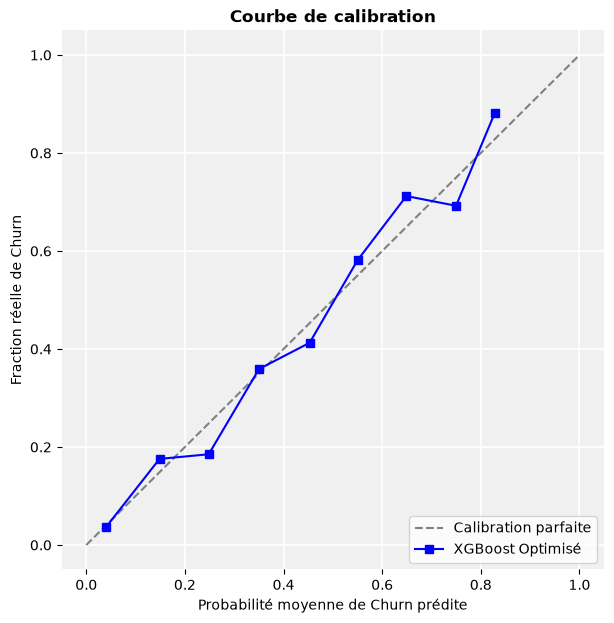

In [20]:
#Calcul des probabilités de prédictions pour XGBoost
y_pred_proba_XGB = searchCV_xgb.predict_proba(X_test)[:, 1]

# Calcul du Brier score pour XGBoost
brier_xgb = brier_score_loss(y_test, y_pred_proba_XGB)
print(f"Brier Score - XGBoost Optimisé      : {brier_xgb:.4f}")


fig, ax = plt.subplots(figsize=(7, 7))

#titre de la courbe            
titre= "Courbe de calibration"

# Tracer la ligne parfaite manuellement au début
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration parfaite')

# Tracer la courbe de calibration sur l'axe 'ax'
tracer_courbe_calibartion(y_test, y_pred_proba_XGB, label="XGBoost Optimisé", ax=ax, couleur="blue", titre=titre, affichage_points=True)
#Sauvegrder l'image
plt.savefig('../reports/figures/courbe_calibration_xgboost.png', dpi=300, bbox_inches='tight')
# On affiche le résultat combiné
plt.show()

**`Le score de Brier (0.1354)`** est proche de 0, ce qui confirme que le XGBoost commet très peu d'erreurs dans l'évaluation de ses probabilités. La courbe de clibration le valide visuellement.

#### <u>Interprétation de la courbe de calibration</u>

La courbe suit de très près la ligne en pointillés (qui représente la calibration parfaite), ce qui démontre une excellente fiabilité globale des probabilités prédites. 

En analysant le graphique plus en détail, on distingue trois zones clés :
- **Zone des probabilités basses à moyennes (~4 % à 35 %)** : La courbe colle presque parfaitement à la diagonale. Au niveau du Point 4 (35.0 % prédit vs 35.9 % réel), le modèle est quasiment parfait avec moins de 1 % d'écart.
- **Zone des probabilités moyennes-hautes (55 % à 65 %)** : La courbe se situe légèrement au-dessus de la diagonale. Le modèle est ici en sous-confiance (sous-estimation) : lorsqu'il prédit un risque de 64.9 % (Point 7), le taux de churn réel constaté est supérieur, à 71.2 %.
- **Zone des probabilités très élevées (> 75 %)** : On observe une oscillation de la courbe probablement due aux faibles effectifs. Le modèle passe d'abord par une phase de sur-confiance à 75.0 % (point 8, où le churn réel n'est que de 69.2 %), avant de repasser en sous-confiance au Point 9 (82.8 % prédit vs 88.1 % réel). 

Le modèle est particulièrement performant dans la zone de scoring intermédiaire, ce qui sécurise la confiance accordée aux scores opérationnels et ne nécessite pas de calibrer d'avantage.

## 7. Portrait-Robot des clients à risque (Seuil >= 0.12)

Nous allons dresser le portrait des clients sur le départ en analysant nos données de test tout en se basant sur le seuil 0,12.

In [21]:
# Copie du jeu de test pour l'analyse
df_analyse = X_test.copy()
portrait_robot = portrait_robot_clients_churn(df_analyse, y_pred_proba_XGB)
portrait_robot.head()


--- PORTRAIT-ROBOT : COMPARAISON DES DEUX SEGMENTS CLIENTS ---


,tenure,MonthlyCharges,TotalCharges,charge_par_mois_tenure,ratio_evolution_facture,SeniorCitizen,%_Contrat_Mois_par_Mois,%_Contrat_1_An,%_Contrat_2_Ans
segment_marketing,,,,,,,,,
Ne pas cibler (Fidèle),48.223,51.631,2822.365,50.462,1.009,0.068,7.8,34.3,57.8
À cibler (Risque >= 12%),21.537,72.018,1815.944,63.182,1.214,0.215,84.8,13.0,2.2


Le filtrage de notre base de test via notre seuil optimal de 12 % permet d'isoler la population ciblée et d'en dessiner le profil comportemental et financier. L'analyse révèle trois déclencheurs majeurs du churn :  
* **La volatilité des nouveaux clients :** l'ancienneté moyenne des clients à risque est de seulement 21,5 mois (tenure < 24 mois).   
* **Le poids des frais mensuels :** les clients à risque affichent des frais mensuels plus élevés. Le prix reste un facteur de sensibilité déterminant face à la concurrence.  
* **L'instabilité facturière :** les variations brutales ou imprévues d'un mois sur l'autre sur la facture agissent peuvent briser la confiance du client et déclenchant la décision de résiliation.

Maintenant que nous avons validé la fiabilité de notre seuil à 12 % et identifié le profil précis des clients à risque, nous allons mesurer l'impact budgétaire exact de cette stratégie de ciblage en la comparant financièrement à notre modèle de Baseline.


## 8. Analyse comparative (XGBoost vs Baseline)

### 8.1 Performances globales

#### 8.1.1 Rapport de classification et AUC (tableau comparatif)


| Métrique Évaluée (Jeu de Test) | Régression Logistique (Baseline) | XGBoost (Optimisé) | Évolution / Impact |
| :--- | :---: | :---: | :---: |
| **AUC-ROC** | 0.8413 | **0.8463** | **+0.0050** (Légère hausse) |
| **Accuracy globale** | 73.81 % | **80.48 %** | **+6.67 %** (Forte progression) |
| **Précision (Classe 1 - Churn)** | 0.50 | **0.68** | **+0.18** (Moins de fausses alertes) |
| **Rappel / Recall (Classe 1)** | **0.78** | 0.50 | **-0.28** (Plus de clients ratés) |
| **F1-Score (Classe 1 - Churn)** | **0.61** | 0.58 | **-0.03** (Légère baisse globale) |


Ce premier comparatif technique au seuil standard de 0,50 montre que le XGBoost est plus précis, mais qu'il manque de sensibilité (Rappel de 0,50).  
Inversement, la Régression Logistique capte beaucoup de churneurs au prix d'un énorme gaspillage budgétaire (Précision de 0,50).  
Nous allons maintenant analyser comment ces deux modèles se comportent financièrement lorsque l'on fait varier leurs volumes de ciblage grâce aux courbes de profit cumulé (Top K%).

#### 8.1.2. Courbes ROC

In [35]:

# Recharger le modèle baseline depuis le fichier
model_charge = joblib.load("../models/baseline.joblib")

# Utiliseration de predict_proba sur les données de test (X_test)
# On récupère la deuxième colonne [:, 1] pour avoir la probabilité de Churn (classe 1)
y_proba_lr_charge = model_charge.predict_proba(X_test)[:, 1]

tracer_courbes_roc(y_test, y_pred_proba_XGB, "XGBoost", "blue", y_proba_lr_charge, "Régression Logistique", "red")


* **Capacité de discrimination (séparation des classes) équivalente :** les trajectoires de la courbe bleue (XGBoost Optimisé) et de la courbe rouge (Régression Logistique) sont quasiment confondues sur l'ensemble du graphique. Le XGBoost surpasse très légèrement la Baseline avec un score d'AUC de 0,8463 contre 0,8413 (soit un écart minime de +0,0050).

* **Comportement à faible taux de fausses alertes :** Dans la zone où le taux de Faux Positifs (FP) se situe entre 10 % et 30 % (axe X), la courbe bleue du XGBoost se détache très légèrement au-dessus de la courbe rouge. Cela indique que pour un niveau de fausses alertes modéré, le XGBoost intercepte un volume de vrais churneurs légèrement supérieur à la Baseline.<br><br>
Les deux modèles disposent donc d'une puissance de discrimination presque identique. Pour valider le modèle le plus performant, il est donc indispensable d'analyser la fiabilité statistique de leurs probabilités via la courbe de calibration.


#### 8.1.3. Matrices de confusion

Graphique sauvegardé sous : ../reports/figures/matrices_confusion_XGBoost_Regression logistique.png


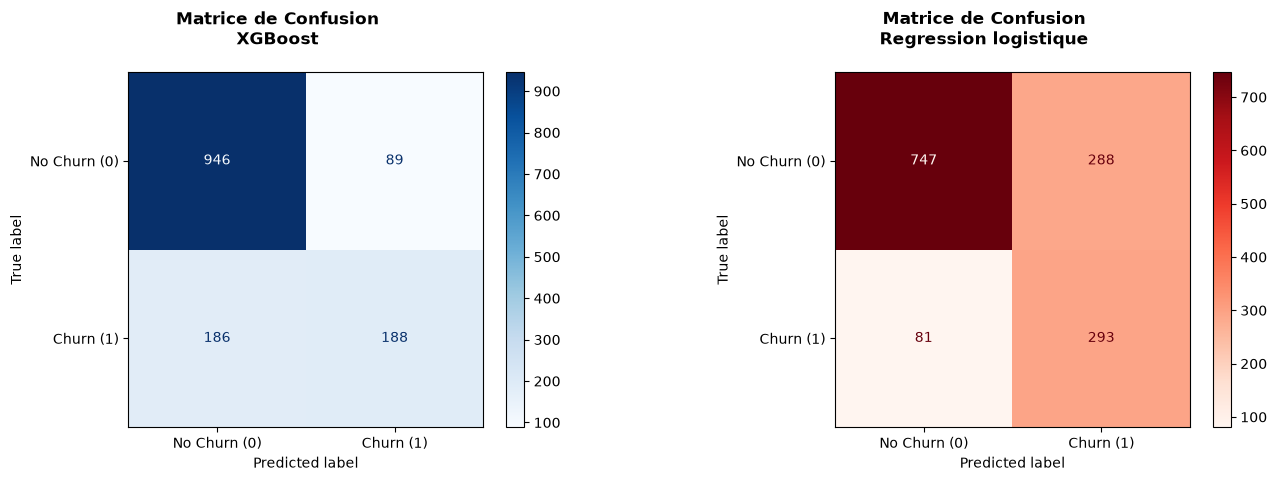

In [23]:
y_pred_baseline = model_charge.predict(X_test)
y_pred_XGB = searchCV_xgb.predict(X_test)
#afficher_matrice_confusion(y_test, y_pred_baseline, "Regression logistique")
tracer_matrices_confusion(y_test, y_pred_XGB, "XGBoost", y_pred_baseline, "Regression logistique")

**Régression Logistique (Baseline)** : détecte beaucoup de vrais positifs (293 VP), mais au prix d'un nombre immense de fausses alertes (288 FP).

**XGBoost (Modèle Optimisé)** : Il est très prudent. Il réduit drastiquement les fausses alertes à seulement 89 FP, mais il rate plus de clients réels (186 FN).  
La matrice de confusion seule ne permet pas de trancher de manière définitive, car le choix dépend du coût financier que l'entreprise attribue à un FP par rapport à un FN.
On peut juste constater qu'on gagne en précisin (on passe de 50% à 68%)

### 8.2. Fiabilité des probabilités

#### 8.2.1. Courbes de calibration et du seuil de Brier

Brier Score - Régression Logistique : 0.1688
Brier Score - XGBoost Optimisé      : 0.1354


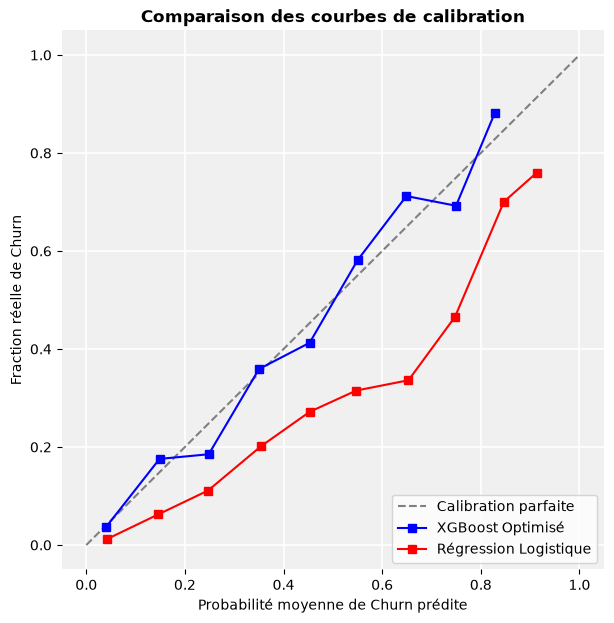

In [24]:
fig, ax = plt.subplots(figsize=(7, 7))
#titre de la courbe            
titre= "Comparaison des courbes de calibration"
# tracer la ligne parfaite manuellement au début
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration parfaite')

# Dessiner les deux fois la même fonction en lui donnant le même axe 'ax'
tracer_courbe_calibartion(y_test, y_pred_proba_XGB, label="XGBoost Optimisé", ax=ax, couleur="blue", titre=titre, affichage_points=False)
tracer_courbe_calibartion(y_test, y_proba_lr_charge, label="Régression Logistique", ax=ax, couleur="red", titre=titre, affichage_points=False)

# Calcul du Brier score pour XGBoost
brier_xgb = brier_score_loss(y_test, y_pred_proba_XGB)
# Calcul du Brier score pour la Régression Logistique
brier_lr = brier_score_loss(y_test, y_proba_lr_charge)


print(f"Brier Score - Régression Logistique : {brier_lr:.4f}")
print(f"Brier Score - XGBoost Optimisé      : {brier_xgb:.4f}")
#Sauvegarder l'image
plt.savefig('../reports/figures/courbes_calibration_xgboost_Regressin_Logistique.png', dpi=300, bbox_inches='tight')
# On affiche le résultat combiné
plt.show()

* La courbe de calibration du **`XGBoost`** est la plus proche de la diagonale, ce qui montre un modèle mathématiquement aligné avec la réalité.  
* La courbe de la **`régression Logistique`** montre un modèle trop optimiste avec des probabilités qui sous-estiment systématiquement le risque de churn.<br>     
**Score de Brier (Brier Score Loss)**
* XGBoost (0,1354) : ce score très bas confirme que le XGBoost commet très peu d'erreurs dans l'évaluation de ses probabilités individuelles.

* Régression Logistique (0,1688) : ce score plus élevé matérialise l'écart que nous voyons sur le graphique. Il prouve que la Régression Logistique souffre d'un biais important qui fausse la distribution de ses probabilités.

### 8.3. Rentabilité et Impact Métier

#### 8.3.1. Courbes de profit Cumulé (Top K%)

Le graphique suivant met en concurrence le comportement budgétaire global de nos deux modèles.

In [28]:
cout_offre=15
valeur_sauvee=120
seuil_optimal_XGB, profit_max_XGB, profits_XGB = simuler_profits_top_k(y_test, y_pred_proba_XGB, cout_offre, valeur_sauvee)
seuil_optimal_LR, profit_max_LR, profits_LR = simuler_profits_top_k(y_test, y_proba_lr_charge, cout_offre, valeur_sauvee)

tracer_courbes_profit_top_k(profits_XGB, "XGB", seuil_optimal_XGB, profits_LR, "LR", seuil_optimal_LR)

print(f"XGBoost - Budget Optimal : Il faut cibler le Top {seuil_optimal_XGB}% des clients les plus risqués.")
print(f"Profit maximum pour cette stratégie : {profit_max_XGB:,.2f} €")


print(f"\nRégression logistique- Budget Optimal : Il faut cibler le Top {seuil_optimal_LR}% des clients les plus risqués.")
print(f"Profit maximum pour cette stratégie : {profit_max_LR:,.2f} €")



XGBoost - Budget Optimal : Il faut cibler le Top 60% des clients les plus risqués.
Profit maximum pour cette stratégie : 29,565.00 €

Régression logistique- Budget Optimal : Il faut cibler le Top 58% des clients les plus risqués.
Profit maximum pour cette stratégie : 29,625.00 €


* **Sommets identiques :** les deux courbes atteignent un profit maximal quasi équivalent **`(environ 29 600 €)`** à des volumes très proches (Top 60 % pour le XGBoost contre Top 58 % pour la Régression Logistique).<br>
* **La supériorité du XGBoost (Top 30 % à 45 %) :** l'avantage du XGBoost se révèle de manière très nette lorsque l'entreprise choisit d'adopter un budget modéré. Dans cette zone allant de 30 % à 45 % de la base ciblée, la courbe bleue se situe systématiquement au-dessus de la courbe rouge. Cela prouve que pour une stratégie de rétention sélective, le XGBoost trie les clients à risque de manière beaucoup plus efficace et génère un meilleur retour sur investissement que la Baseline.

#### 8.3.2. Optimisation du Seuil de Décision

Ce graphique superposé permet de comprendre permet de compléter l'analyse du profit précédente.

In [29]:
seuil_optimal_XGB, profit_max_XGB, profits_XGB = calculer_seuil(y_test, y_pred_proba_XGB, cout_offre=15, valeur_sauvee=120)
seuil_optimal_LR, profit_max_LR, profits_LR = calculer_seuil(y_test, y_proba_lr_charge, cout_offre=15, valeur_sauvee=120)
tracer_courbes_profit_seuils(seuil_optimal_XGB, "XGBoost", profits_XGB, seuil_optimal_LR, "LR", profits_LR)

print(f"Seuil XGBoost optimal : {seuil_optimal_XGB:.2f} (soit {seuil_optimal_XGB*100:.0f}%)")
print(f"Profit net maximum généré sur le jeu de test : {profit_max_XGB:,.2f} €")

print(f"Seuil LR optimal : {seuil_optimal_LR:.2f} (soit {seuil_optimal_LR*100:.0f}%)")
print(f"Profit net maximum généré sur le jeu de test : {profit_max_LR:,.2f} €")




Seuil XGBoost optimal : 0.12 (soit 12%)
Profit net maximum généré sur le jeu de test : 29,565.00 €
Seuil LR optimal : 0.29 (soit 29%)
Profit net maximum généré sur le jeu de test : 29,610.00 €


Pour rappel:
* XGBoost a une précision = 0,68 et un recall=0,50.  
* La régressio logistique a une précison = 0,50 et un recall=0,78.  

**`XGBoost (Bleue) :`** 
Au seuil de 0,50, XGBoost affiche une forte précision (0,68) mais un recall limité (0,50).  
Le modèle maximise le profit en abaissant son seuil à 12 %. Cette stratégie permet de corriger le recall en capturant plus de cas de churn, tout en s'appuyant sur la haute précision du modèle pour éviter une explosion incontrôlée des coûts liés aux faux positifs.  
**`Régression Logistique (Rouge) :`**  
 À l'inverse, la Régression Logistique présente un excellent recall initial (0,78) mais une faible précision (0,50), générant un trop grand nombre de faux positifs à 15 €. Le seuil de 29 % permet de corriger ce problème et maximiser la rentabilité.  


Ce décalage confirme la mauvaise calibration de la Régression Logistique. Comme elle sous-estime le risque réel (Brier Score de 0.1688), elle est obligée de compenser ce biais en fixant un seuil de tolérance plus haut (29 %) pour s'arrêter au bon volume de clients. Le seuil de 12 % du XGBoost est un choix robuste. 


#### 8.3.3. Évaluation de l'efficacité du ciblage (Lift du modèle retenu : XGBoost)

In [27]:
tracer_courbe_lift(X_test, y_test, searchCV_xgb)

* **Aux premiers déciles** : le lift culmine à environ 3,7. Cela montre que sur les clients classés comme **`"à risque"`** par XGBoost, le modèle est 3,7 fois plus performant que le hasard pour cibler la classe d'intérêt (les positifs).
* **Au point optimal (Top 60 %)** : le modèle affiche un lift d'environ **`1.6`**, c'est le point d'équilibre parfait pour optimiser le budget marketing tout en capturant **`96 %`** de la totalité des résiliations du dataset.  
Le lift de 1.6 signifie qu'en ciblant ce Top 60 % trié par XGBoost, la campagne marketing est 1.6 fois plus efficace qu'un ciblage au hasard.  
Au lieu de retenir seulement 60 % des churners (comme le ferait le hasard), nous allons avoir :   
$\text{60 \% de la population} \times 1.6\text{ (Lift)} = \mathbf{96 \%}\text{ de la totalité des churners}$

## 9. Génération du rapport final et sauvegarde du modèle

### 9.1. Génération du rapport final

In [19]:

generate_rapport_final() 

Metrics.py est exécuté depuis le dossier :  c:\Users\ReMarkt\Documents\Scoring-de-churn-client\notebooks
Chemin du dossier src : c:\Users\ReMarkt\Documents\Scoring-de-churn-client\src
Chemin du rapport : c:\Users\ReMarkt\Documents\Scoring-de-churn-client\reports\rapport_metriques_final.md
Le rapport final intégrant les 3 consignes et vos vrais chiffres a été sauvegardé avec succès !


### 9.2. Sauvegarde du modèle

In [ ]:

# Fichier de sortie : baseline_logistic_regression.joblib
joblib.dump(searchCV_xgb, "../models/xgb.joblib")

# Génération du fichier Scoring CSV demandé
scoring_df = pd.DataFrame({
    'customerID': id_test,
    'proba_churn': searchCV_xgb.predict_proba(X_test)[:, 1],
    'label_pred': searchCV_xgb.predict(X_test)
})
scoring_df.to_csv("../reports/scoring_outputs_final.csv", index=False)

print("Modèle ré-entraîné et fichier CSV généré avec succès.")

Modèle ré-entraîné et fichier CSV généré avec succès.
